<a href="https://colab.research.google.com/github/ayelencalo/TP_vision_computadora_2/blob/main/Agus_FINAL_TP_Final_Futbol_Deteccion_Tracking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚽ Visión por Computadora II – CEIA – FIUBA
## Trabajo Práctico: Detección de Jugadores, Pelota y Árbitros en Fútbol
### **Grupo 11**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FIUBA-Posgrado-Inteligencia-Artificial/vision_computadora_II/blob/main/Trabajo_Practico/TP_Final_Futbol_Deteccion_Tracking.ipynb)

---

### 📋 Diagrama de Etapas del Sistema (Fase A: Entrenamiento y Evaluación)
```
[01. Dataset] ────────► [02. EDA y Preproc.] ────────► [03. Fine-tuning YOLO]
 • Kaggle (53k img)       • Limpieza (sin labels)       • Baseline 640
 • 4 clases               • Muestreo 50%                • Variante 1280 (alta res)
 • splits train/val/test  • Conteo & Pelota ~5px        • Variante P2 (objetos chicos)
                          • Data Augmentation           • 15 épocas / save_period=5
                                                               │
                                                               ▼
[06. Video Match] ◄──── [05. Posprocesamiento] ◄───── [04. Evaluación]
 • Inferencia frame-by-   • Conf. Threshold (0.35)      • mAP@50 y mAP@50-95
   frame con OpenCV       • NMS IoU (0.60)              • Matriz de confusión
 • HUD estadístico        • Disputas cuerpo a cuerpo      (Arquero vs. Jugador)
 • Video MP4 exportado                                  • Modelo ganador
```

---
### 🎯 Especificaciones de este Notebook Unificado:
1. **Ejecutable de punta a punta** en **Google Colab** (o localmente) por cualquier usuario.
2. **Curación estricta de datos:** Eliminación de imágenes sin anotaciones (fondos puros vacíos) y **submuestreo determinístico al 50% de la base** para una ejecución ágil y eficiente.
3. **Persistencia y Resiliencia en Colab:**
   * Soporte opcional para guardar checkpoints directamente en **Google Drive**.
   * Guardado cada 5 épocas (`save_period=5`) para permitir reanudar el entrenamiento (`resume=True`) ante desconexiones.
   * Fijación rigurosa de semillas aleatorias (`seed=42`, `deterministic=True`) para garantizar reproducibilidad.
4. **Comparación Formal de los 3 Modelos:**
   * **Modelo 1 (Baseline Baja Resolución):** $640 	imes 640$, pesos preentrenados COCO.
   * **Modelo 2 (Alta Resolución):** $1280 	imes 1280$, para recuperar la pelota pequeña de $pprox 5$ px.
   * **Modelo 3 (Cabeza P2 para Objetos Pequeños):** $640 	imes 640$, arquitectura `yolov8s-p2.yaml` con stride 4.
5. **Evaluación, Posprocesamiento y Video:**
   * Matriz de confusión detallada (arquero vs. jugador de campo).
   * Calibración de umbrales `conf` y `iou` (NMS).
   * Generación de video de partido con HUD informativo en tiempo real.


## 1. Configuración del Entorno, Google Drive y Reproducibilidad

Configuramos las dependencias, inicializamos las semillas pseudoaleatorias para garantizar reproducibilidad matemática y configuramos la ruta de persistencia (con opción de montar Google Drive si ejecutamos en Colab).


In [3]:
# Verificación de entorno, semillas y configuración de almacenamiento
import sys
import os
import random
import shutil
from pathlib import Path

# 1. Detección de entorno
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🚀 Ejecutando en Google Colab")
    get_ipython().system("pip install -q ultralytics kagglehub opencv-python matplotlib seaborn pyyaml")

    # Montaje opcional de Google Drive para persistencia de modelos ante reinicios
    MOUNT_DRIVE = True  # Cambiar a True si deseas persistir directamente en tu Drive personal
    if MOUNT_DRIVE:
        from google.colab import drive
        drive.mount('/content/drive')
        RUNS_DIR = Path("/content/drive/MyDrive/CEIA_VpC2_TP/runs")
    else:
        RUNS_DIR = Path("/content/runs")
else:
    print("💻 Ejecutando en entorno Local")
    if sys.platform == 'win32':
        os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
    RUNS_DIR = Path("Trabajo_Practico/runs")

RUNS_DIR.mkdir(parents=True, exist_ok=True)
print(f"📁 Directorio de persistencia de modelos: {RUNS_DIR}")

# 2. Reproducibilidad: Fijar semillas aleatorias
SEED = 42
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

import torch
import numpy as np
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

import cv2
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from tqdm import tqdm
import kagglehub

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style="whitegrid")

DEVICE = "0" if torch.cuda.is_available() else "cpu"
print(f"\nDispositivo PyTorch: {DEVICE}")
if torch.cuda.is_available():
    print(f" - GPU: {torch.cuda.get_device_name(0)}")
    print(f" - VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"Semilla de reproducibilidad fijada: {SEED}")


🚀 Ejecutando en Google Colab
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 7.9 MB/s eta 0:00:00
Mounted at /content/drive
📁 Directorio de persistencia de modelos: /content/drive/MyDrive/CEIA_VpC2_TP/runs
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.

Dispositivo PyTorch: 0
 - GPU: Tesla T4
 - VRAM: 15.64 GB
Semilla de reproducibilidad fijada: 42


## 2. Etapa 01: Descarga y Preparación del Dataset

Descargamos automáticamente el dataset oficial desde Kaggle:
* **Dataset:** [`oussamamoussa/foot-ball-dataset`](https://www.kaggle.com/datasets/oussamamoussa/foot-ball-dataset)
* **Formato:** YOLO estándar (anotaciones normalizadas `[class_id, xc, yc, w, h]`).
* **Clases de interés:**
  * `0: ball` (pelota)
  * `1: goalkeeper` (arquero)
  * `2: player` (jugador de campo)
  * `3: referee` (árbitro)

Utilizamos `kagglehub.dataset_download`, que descarga datasets públicos sin requerir credenciales manuales complejas.


In [4]:
# Descarga o localización automática del dataset
DATASET_HANDLE = "oussamamoussa/foot-ball-dataset"

local_candidates = [
    Path("Trabajo_Practico/data/football_dataset"),
    Path("data/football_dataset"),
    Path("../data/football_dataset"),
    Path(os.path.expanduser("~/.cache/kagglehub/datasets/oussamamoussa/foot-ball-dataset/versions/1"))
]

dataset_path = None
for candidate in local_candidates:
    if candidate.exists() and (candidate / "train" / "images").exists():
        dataset_path = candidate.resolve()
        print(f" Dataset encontrado localmente en: {dataset_path}")
        break

if dataset_path is None:
    print(f"📥 Descargando dataset desde Kaggle ({DATASET_HANDLE})...")
    downloaded_dir = kagglehub.dataset_download(DATASET_HANDLE)
    dataset_path = Path(downloaded_dir).resolve()
    print(f" Dataset descargado exitosamente en: {dataset_path}")

print(f"\nRuta base del dataset: {dataset_path}")


📥 Descargando dataset desde Kaggle (oussamamoussa/foot-ball-dataset)...


100%|██████████| 3.72G/3.72G [03:43<00:00, 17.9MB/s]

Extracting files...


 Dataset descargado exitosamente en: /root/.cache/kagglehub/datasets/oussamamoussa/foot-ball-dataset/versions/1

Ruta base del dataset: /root/.cache/kagglehub/datasets/oussamamoussa/foot-ball-dataset/versions/1


## 3. Curación de Datos: Eliminación de Imágenes sin Etiqueta y Submuestreo al 50%

### 🧹 Requerimientos del Preprocesamiento:
1. **Eliminación de Imágenes Vacías:** En la base original existen imágenes sin ninguna anotación (archivo `.txt` de tamaño 0 bytes o vacío). En un partido de fútbol profesional es imposible que no haya ni jugadores, ni arqueros, ni árbitros ni pelota. Por ende, **filtramos y eliminamos todas las imágenes sin anotaciones**.
2. **Submuestreo al 50%:** Para lograr una experimentación ágil y permitir comparar 3 arquitecturas de modelos en tiempos razonables de Colab, seleccionamos exactamente el **50% de las imágenes con anotaciones válidas** en cada split, empleando `random.seed(42)`.


In [5]:
# Filtrado de imágenes vacías y generación de split al 50%
splits_dir = Path("splits_50pct") if IN_COLAB else Path("Trabajo_Practico/data/splits_50pct")
splits_dir.mkdir(parents=True, exist_ok=True)

class_names = ["ball", "goalkeeper", "player", "referee"]
subsample_records = []
split_files_map = {}

random.seed(SEED)

for split in ["train", "valid", "test"]:
    img_dir = dataset_path / split / "images"
    lbl_dir = dataset_path / split / "labels"

    valid_img_paths = []
    empty_label_count = 0
    missing_count = 0

    # Recorrido ultra-rápido de entradas de directorio
    with os.scandir(img_dir) as entries:
        for entry in entries:
            if entry.is_file() and entry.name.lower().endswith((".jpg", ".png", ".jpeg")):
                lbl_file = lbl_dir / f"{Path(entry.name).stem}.txt"
                if not lbl_file.exists():
                    missing_count += 1
                elif lbl_file.stat().st_size == 0:
                    empty_label_count += 1
                else:
                    # Validar que tenga al menos una línea con contenido
                    valid_img_paths.append(str(Path(entry.path).resolve()).replace("\\", "/"))

    total_imgs = len(valid_img_paths) + empty_label_count + missing_count

    # Ordenar determinísticamente antes de barajar
    valid_img_paths.sort()
    random.shuffle(valid_img_paths)

    # Seleccionar exactamente el 50%
    n_sample = len(valid_img_paths) // 2
    sampled_50pct = valid_img_paths[:n_sample]

    # Guardar lista de rutas de imágenes
    split_txt = splits_dir / f"{split}_50pct.txt"
    with open(split_txt, "w", encoding="utf-8") as f:
        f.write("\n".join(sampled_50pct) + "\n")

    split_files_map[split] = split_txt.resolve()

    subsample_records.append({
        "Split": split,
        "Total Original": total_imgs,
        "Sin Etiqueta (Eliminadas)": empty_label_count,
        "Válidas con Anotación": len(valid_img_paths),
        "50% Seleccionado para TP": len(sampled_50pct)
    })

df_curacion = pd.DataFrame(subsample_records)
print("📊 Resumen de Limpieza y Submuestreo al 50%:")
display(df_curacion)

total_eliminadas = df_curacion["Sin Etiqueta (Eliminadas)"].sum()
total_entrenamiento_50 = df_curacion["50% Seleccionado para TP"].sum()
print(f"\n Total de imágenes vacías eliminadas: {total_eliminadas:,}")
print(f" Total de imágenes en el dataset final (50% curado): {total_entrenamiento_50:,}")


📊 Resumen de Limpieza y Submuestreo al 50%:


,Split,Total Original,Sin Etiqueta (Eliminadas),Válidas con Anotación,50% Seleccionado para TP
0,train,46511,2162,44349,22174
1,valid,4757,317,4440,2220
2,test,2177,141,2036,1018



 Total de imágenes vacías eliminadas: 2,620
 Total de imágenes en el dataset final (50% curado): 25,412


### 3.1 Configuración de `data_football_50pct.yaml` para Ultralytics YOLO

Ultralytics YOLO permite especificar un archivo `.txt` con la lista de imágenes para cada split. Generamos el archivo de configuración correspondiente apuntando a nuestras listas del 50%.


In [6]:
# Generación del archivo YAML definitivo del dataset curado
yaml_50pct_config = {
    "path": str(dataset_path).replace("\\", "/"),
    "train": str(split_files_map["train"]).replace("\\", "/"),
    "val": str(split_files_map["valid"]).replace("\\", "/"),
    "test": str(split_files_map["test"]).replace("\\", "/"),
    "nc": len(class_names),
    "names": {i: name for i, name in enumerate(class_names)}
}

yaml_50pct_path = Path("data_football_50pct.yaml") if IN_COLAB else Path("Trabajo_Practico/configs/data_football_50pct.yaml")
yaml_50pct_path.parent.mkdir(parents=True, exist_ok=True)

with open(yaml_50pct_path, "w", encoding="utf-8") as f:
    yaml.dump(yaml_50pct_config, f, sort_keys=False, default_flow_style=False)

print(f" Configuración guardada en: {yaml_50pct_path.resolve()}")
print(yaml.dump(yaml_50pct_config, default_flow_style=False))


 Configuración guardada en: /content/data_football_50pct.yaml
names:
  0: ball
  1: goalkeeper
  2: player
  3: referee
nc: 4
path: /root/.cache/kagglehub/datasets/oussamamoussa/foot-ball-dataset/versions/1
test: /content/splits_50pct/test_50pct.txt
train: /content/splits_50pct/train_50pct.txt
val: /content/splits_50pct/valid_50pct.txt



## 4. Etapa 02: Análisis Exploratorio de Datos (EDA) y Preprocesamiento

Analizamos las características estadísticas y espaciales del dataset curado:
1. **Conteo por clase:** Cuantificación del desbalance (`player >> resto`).
2. **Dimensiones de Bounding Boxes:** Demostración de que la **pelota tiene $\approx 5$ px de lado (mediana a 640x640)**.
3. **Distribución espacial:** Heatmaps de posiciones de jugadores y pelota en el campo.
4. **Visualización cualitativa:** Cuadros anotados con colores por rol y zoom sobre la pelota.
5. **Estrategia de Data Augmentation:** Transformaciones permitidas vs. desaconsejadas en fútbol.


In [7]:
# Extracción de estadísticas de anotaciones en el conjunto de validación curado
def extract_box_statistics(image_list_txt, max_samples=2000):
    with open(image_list_txt, "r", encoding="utf-8") as f:
        img_paths = [p.strip() for p in f if p.strip()]
    if max_samples:
        img_paths = img_paths[:max_samples]

    box_records = []
    for img_p_str in tqdm(img_paths, desc="Analizando Bounding Boxes"):
        img_p = Path(img_p_str)
        lbl_p = img_p.parent.parent / "labels" / f"{img_p.stem}.txt"
        if not lbl_p.exists():
            continue

        with open(lbl_p, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls_id = int(parts[0])
                    xc, yc, w, h = map(float, parts[1:5])
                    box_records.append({
                        "image": img_p.stem,
                        "class_id": cls_id,
                        "class_name": class_names[cls_id] if cls_id < len(class_names) else f"cls_{cls_id}",
                        "xc": xc,
                        "yc": yc,
                        "w": w,
                        "h": h,
                        "w_px_640": w * 640,
                        "h_px_640": h * 640,
                        "area_rel": w * h,
                        "aspect_ratio": h / (w + 1e-6)
                    })
    return pd.DataFrame(box_records)

df_boxes_eda = extract_box_statistics(split_files_map["valid"])
print(f"\nTotal de objetos analizados en validación: {len(df_boxes_eda):,}")
display(df_boxes_eda.head())


Analizando Bounding Boxes: 100%|██████████| 2000/2000 [00:01<00:00, 1028.01it/s]



Total de objetos analizados en validación: 37,118


,image,class_id,class_name,xc,yc,w,h,w_px_640,h_px_640,area_rel,aspect_ratio
0,ds45_744b27_3_7_png_jpg.rf.7017bc606f434a1281f...,2,player,0.752344,0.427344,0.007812,0.028906,5.0,18.5,0.000226,3.699526
1,ds45_744b27_3_7_png_jpg.rf.7017bc606f434a1281f...,2,player,0.337500,0.432812,0.007812,0.035156,5.0,22.5,0.000275,4.499424
2,ds45_744b27_3_7_png_jpg.rf.7017bc606f434a1281f...,2,player,0.373437,0.429688,0.011719,0.033594,7.5,21.5,0.000394,2.866422
3,ds45_744b27_3_7_png_jpg.rf.7017bc606f434a1281f...,2,player,0.390625,0.446875,0.012500,0.035156,8.0,22.5,0.000439,2.812275
4,ds45_744b27_3_7_png_jpg.rf.7017bc606f434a1281f...,2,player,0.659375,0.492188,0.009375,0.039062,6.0,25.0,0.000366,4.166222


### 4.1 Distribución de Clases y Severo Desbalance (`player >> resto`)


,Instancias,Porcentaje (%),Ratio vs Pelota
class_name,,,
ball,1588,4.28,1.00
goalkeeper,919,2.48,0.58
player,31829,85.75,20.04
referee,2782,7.50,1.75


/tmp/ipykernel_1266/498552045.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_by_class.index, y=counts_by_class.values, palette=palette, ax=axes[0])
/tmp/ipykernel_1266/498552045.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_by_class.index, y=counts_by_class.values, palette=palette, ax=axes[1])


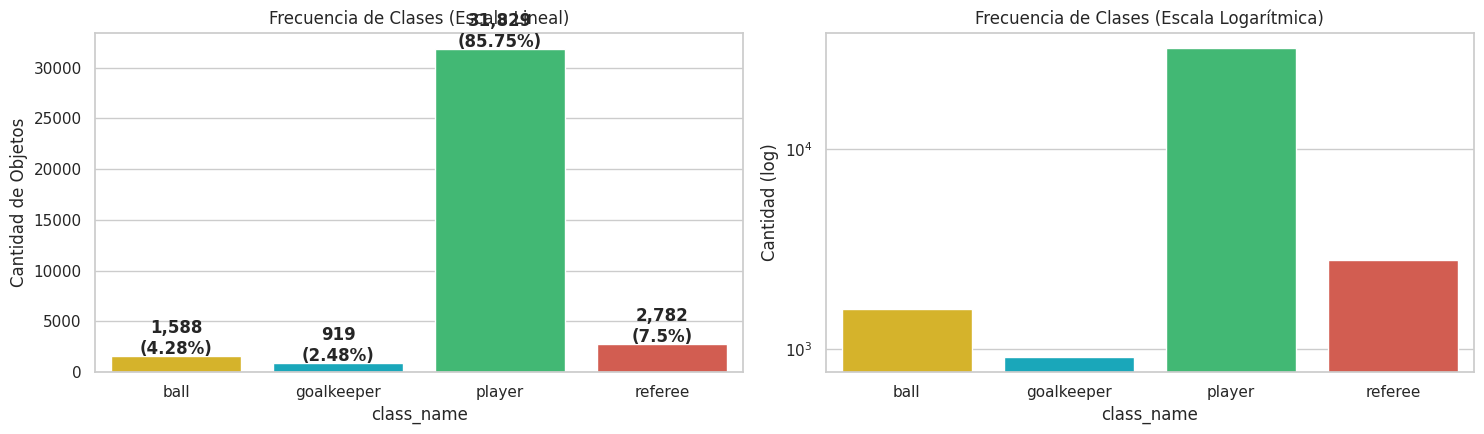

In [8]:
# Análisis cuantitativo del desbalance de clases
counts_by_class = df_boxes_eda["class_name"].value_counts().reindex(class_names).fillna(0).astype(int)
pcts_by_class = (counts_by_class / counts_by_class.sum() * 100).round(2)

df_class_dist = pd.DataFrame({
    "Instancias": counts_by_class,
    "Porcentaje (%)": pcts_by_class,
    "Ratio vs Pelota": (counts_by_class / max(1, counts_by_class["ball"])).round(2)
})
display(df_class_dist)

# Visualización gráfica de distribución
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
palette = ["#f1c40f", "#00bcd4", "#2ecc71", "#e74c3c"]

sns.barplot(x=counts_by_class.index, y=counts_by_class.values, palette=palette, ax=axes[0])
axes[0].set_title("Frecuencia de Clases (Escala Lineal)")
axes[0].set_ylabel("Cantidad de Objetos")
for i, v in enumerate(counts_by_class.values):
    axes[0].text(i, v + 200, f"{v:,}\n({pcts_by_class.iloc[i]}%)", ha="center", fontweight="bold")

sns.barplot(x=counts_by_class.index, y=counts_by_class.values, palette=palette, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Frecuencia de Clases (Escala Logarítmica)")
axes[1].set_ylabel("Cantidad (log)")

plt.tight_layout()
plt.show()


### 4.2 Dimensiones de Bounding Boxes y Confirmación de la Pelota Pequeña (~5 px)


In [9]:
# Cálculo de dimensiones medianas relativas a 640x640
dim_stats = []
for c in class_names:
    sub = df_boxes_eda[df_boxes_eda["class_name"] == c]
    if len(sub) == 0:
        continue
    dim_stats.append({
        "Clase": c,
        "Ancho Mediano (px@640)": round(sub["w_px_640"].median(), 2),
        "Alto Mediano (px@640)": round(sub["h_px_640"].median(), 2),
        "Lado Promedio (px@640)": round(((sub["w_px_640"] + sub["h_px_640"]) / 2).median(), 2),
        "Aspect Ratio Mediano (h/w)": round(sub["aspect_ratio"].median(), 2)
    })

df_dim = pd.DataFrame(dim_stats)
display(df_dim)

ball_lado = df_dim.loc[df_dim["Clase"] == "ball", "Lado Promedio (px@640)"].values[0]
print(f"📌 Confirmación empírica: Lado mediano de la pelota = {ball_lado:.2f} px (≈ 5 px a 640x640).")

,Clase,Ancho Mediano (px@640),Alto Mediano (px@640),Lado Promedio (px@640),Aspect Ratio Mediano (h/w)
0,ball,4.0,7.50,5.79,1.78
1,goalkeeper,9.0,30.93,19.75,3.50
2,player,9.0,35.00,22.00,3.82
3,referee,9.0,33.00,20.75,3.75


📌 Confirmación empírica: Lado mediano de la pelota = 5.79 px (≈ 5 px a 640x640).


### 4.3 Visualización Cualitativa y Zoom sobre la Pelota


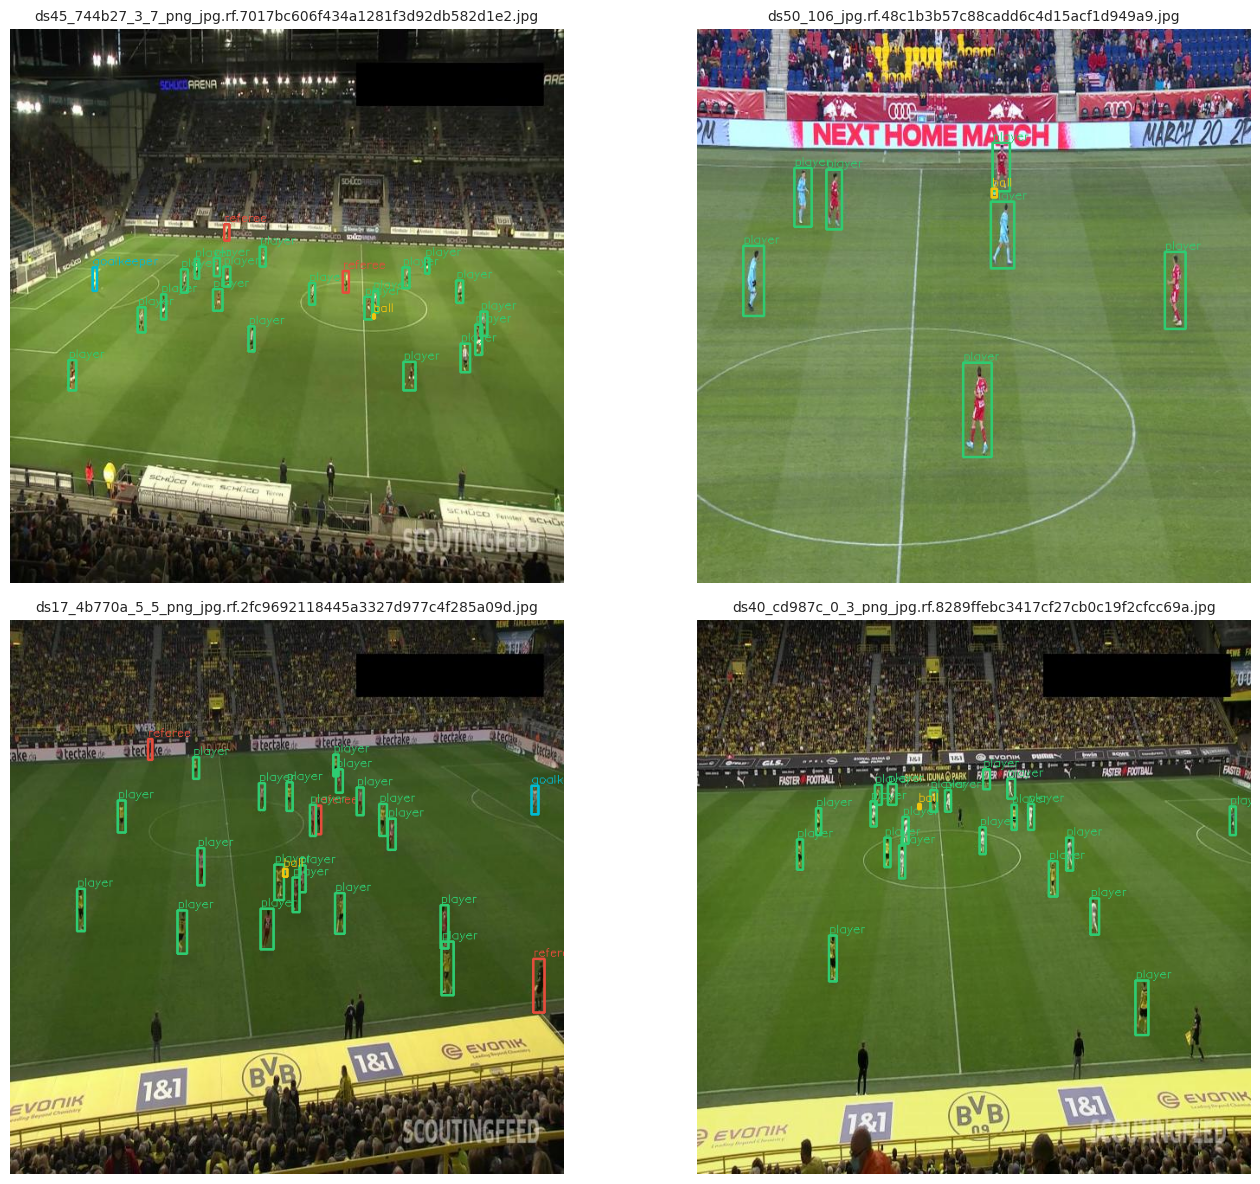

In [10]:
# Función de visualización cualitativa con bounding boxes
CLASS_COLORS_RGB = {
    0: (241, 196, 15),   # ball: Amarillo
    1: (0, 188, 212),    # goalkeeper: Cian
    2: (46, 204, 113),   # player: Verde
    3: (231, 76, 60)     # referee: Rojo
}

def render_sample(img_path_str, ax=None):
    img_p = Path(img_path_str)
    lbl_p = img_p.parent.parent / "labels" / f"{img_p.stem}.txt"

    img = cv2.imread(str(img_p))
    if img is None:
        return None, None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    ball_box = None
    if lbl_p.exists():
        with open(lbl_p, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls_id = int(parts[0])
                    xc, yc, bw, bh = map(float, parts[1:5])
                    xmin = max(0, int((xc - bw / 2.0) * w))
                    ymin = max(0, int((yc - bh / 2.0) * h))
                    xmax = min(w - 1, int((xc + bw / 2.0) * w))
                    ymax = min(h - 1, int((yc + bh / 2.0) * h))

                    color = CLASS_COLORS_RGB.get(cls_id, (255, 255, 255))
                    cv2.rectangle(img_rgb, (xmin, ymin), (xmax, ymax), color, 2)
                    c_name = class_names[cls_id]
                    cv2.putText(img_rgb, c_name, (xmin, max(12, ymin - 3)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

                    if cls_id == 0:
                        ball_box = (xmin, ymin, xmax, ymax)

    if ax:
        ax.imshow(img_rgb)
        ax.axis("off")
        ax.set_title(img_p.name, fontsize=10)
    return img_rgb, ball_box

# Mostrar 4 muestras aleatorias de validación
with open(split_files_map["valid"], "r", encoding="utf-8") as f:
    sample_imgs = [p.strip() for p in f if p.strip()][:4]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
for i, s_p in enumerate(sample_imgs):
    render_sample(s_p, ax=axes.flatten()[i])
plt.tight_layout()
plt.show()


## 5. Etapa 03: Fine-Tuning YOLO – Comparación de 3 Modelos

Para responder rigurosamente a la problemática planteada en el plan, entrenamos y comparamos **3 configuraciones técnicas**:

| Modelo | Resolución | Arquitectura | Justificación Técnica |
| :--- | :---: | :---: | :--- |
| **Modelo 1 (Baseline)** | $640 	imes 640$ | `yolov8s.pt` | Punto de partida para medir precisión, recall y latencia (FPS). |
| **Modelo 2 (Alta Resolución)** | $1280 	imes 1280$ | `yolov8s.pt` | Duplica la densidad de píxeles: la pelota pasa de ~5 px a ~10 px. |
| **Modelo 3 (Cabeza P2)** | $640 	imes 640$ | `yolov8s-p2.yaml` | Agrega un detector de $stride=4$ ($160 	imes 160$) para objetos diminutos sin duplicar la resolución. |

---
### ⚙️ Parámetros de Entrenamiento Unificados:
* **Épocas:** **15 épocas** (`epochs=15`).
* **Persistencia por Checkpoint:** **Cada 5 épocas** (`save_period=5`), guardando `epoch5.pt`, `epoch10.pt`, `epoch15.pt`, `last.pt` y `best.pt`.
* **Resiliencia ante desconexiones:** Soporte para reanudar el entrenamiento con `resume=True`.
* **Semilla fija:** `seed=42`, `deterministic=True`.


In [11]:
# Configuración unificada de entrenamiento para los 3 modelos (15 épocas)
BASE_TRAIN_PARAMS = {
    "data": str(yaml_50pct_path.resolve()),
    "epochs": 15,                  # 15 épocas requeridas
    "save_period": 5,              # Checkpoint de persistencia cada 5 épocas
    "project": str(RUNS_DIR / "train"),
    "seed": SEED,                  # Semilla de reproducibilidad (42)
    "deterministic": True,         # Determinismo en PyTorch
    "save": True,
    "patience": 8,                 # Early stopping
    "exist_ok": True,
    # Data Augmentation adaptado para fútbol:
    "fliplr": 0.5,                 # Flip horizontal simétrico
    "flipud": 0.0,                 # Flip vertical desactivado (gravedad fija)
    "hsv_h": 0.015,
    "hsv_s": 0.7,
    "hsv_v": 0.4,
    "mosaic": 1.0,
    "close_mosaic": 3              # Desactivar mosaico en últimas 3 épocas para estabilizar cajas
}

print("Parámetros de entrenamiento base listos:")
for k, v in BASE_TRAIN_PARAMS.items():
    print(f"  • {k}: {v}")


Parámetros de entrenamiento base listos:
  • data: /content/data_football_50pct.yaml
  • epochs: 15
  • save_period: 5
  • project: /content/drive/MyDrive/CEIA_VpC2_TP/runs/train
  • seed: 42
  • deterministic: True
  • save: True
  • patience: 8
  • exist_ok: True
  • fliplr: 0.5
  • flipud: 0.0
  • hsv_h: 0.015
  • hsv_s: 0.7
  • hsv_v: 0.4
  • mosaic: 1.0
  • close_mosaic: 3


### 5.1 Reanudación de Entrenamiento ante Desconexión (`resume=True`)

Si Google Colab se desconecta durante el entrenamiento, se puede retomar desde el último checkpoint (`last.pt` o `epochX.pt`) ejecutando la siguiente celda:


In [12]:
# Ejemplo: Cómo reanudar un entrenamiento interrumpido
def resume_training_if_interrupted(checkpoint_path):
    """Reanuda el entrenamiento de YOLO desde el último checkpoint guardado."""
    if Path(checkpoint_path).exists():
        print(f"🔄 Reanudando entrenamiento desde checkpoint: {checkpoint_path}")
        model_resume = YOLO(checkpoint_path)
        model_resume.train(resume=True)
    else:
        print(f"No se encontró checkpoint en {checkpoint_path}. Iniciando desde cero.")


In [13]:
# Ejecutar si se desconecta la T4 / L4 del colab
# checkpoint_path = str(RUNS_DIR / "train" / "m2_highres_1280" / "weights" / "last.pt")
# resume_training_if_interrupted(checkpoint_path)

### 5.2 Entrenamiento del Modelo 1: Baseline Baja Resolución (640x640)


In [14]:
# # Modelo 1: Baseline a 640x640
# print("==================================================")
# print("INICIANDO ENTRENAMIENTO: Modelo 1 (Baseline 640)")
# print("==================================================")

# model_1 = YOLO("yolov8s.pt")

# results_m1 = model_1.train(
#     **BASE_TRAIN_PARAMS,
#     imgsz=640,
#     batch=16,
#     name="m1_baseline_640",
#     device=DEVICE
# )

# best_m1_path = RUNS_DIR / "train" / "m1_baseline_640" / "weights" / "best.pt"
# print(f" Pesos Modelo 1 listos en: {best_m1_path}")


### 5.3 Entrenamiento del Modelo 2: Alta Resolución (1280x1280)

Entrenamos a $1280 	imes 1280$ para evaluar el impacto de duplicar la resolución en la detección de la pelota diminuta. Reducimos el batch a 8 para respetar los límites de VRAM de la GPU T4.


In [15]:
# Modelo 2: Alta Resolución (1280x1280)
# print("==================================================")
# print("INICIANDO ENTRENAMIENTO: Modelo 2 (Alta Res 1280)")
# print("==================================================")

# model_2 = YOLO("yolov8s.pt")

# results_m2 = model_2.train(
#     **BASE_TRAIN_PARAMS,
#     imgsz=1280,
#     batch=16,                       # Batch reducido para VRAM a 1280
#     name="m2_highres_1280",
#     device=DEVICE
# )

# best_m2_path = RUNS_DIR / "train" / "m2_highres_1280" / "weights" / "best.pt"
# print(f" Pesos Modelo 2 listos en: {best_m2_path}")


### 5.4 Entrenamiento del Modelo 3: Cabeza Detectora P2 (Stride 4)

Instanciamos la arquitectura `yolov8s-p2.yaml` y transferimos los pesos preentrenados de COCO.


In [16]:
# Modelo 3: Arquitectura con Cabeza P2 para Objetos Pequeños
# print("==================================================")
# print("INICIANDO ENTRENAMIENTO: Modelo 3 (Cabeza P2)")
# print("==================================================")

# model_3 = YOLO("yolov8s-p2.yaml")
# model_3.load("yolov8s.pt")  # Transferencia de pesos COCO

# results_m3 = model_3.train(
#     **BASE_TRAIN_PARAMS,
#     imgsz=640,
#     batch=16,
#     name="m3_p2_head_640",
#     device=DEVICE
# )

# best_m3_path = RUNS_DIR / "train" / "m3_p2_head_640" / "weights" / "best.pt"
# print(f" Pesos Modelo 3 listos en: {best_m3_path}")


## 6. Etapa 04: Evaluación Formal y Comparación de Modelos

Validamos formalmente las 3 variantes sobre el conjunto de validación (`val_50pct.txt`) para responder:
* ¿Mejora la alta resolución (1280) el mAP de la pelota frente al baseline 640?
* ¿Logra la cabeza P2 un recall competitivo en la pelota manteniendo una latencia baja a 640?
* ¿Cómo se comportan las matrices de confusión entre **arquero (`goalkeeper`) vs. jugador (`player`)**?


In [23]:
# Definir las rutas de los pesos apuntando a la carpeta unificada en Drive
best_m1_path = RUNS_DIR / "train" / "m1_baseline_640" / "weights" / "best.pt"
best_m2_path = RUNS_DIR / "train" / "m2_highres_1280" / "weights" / "best.pt"
best_m3_path = RUNS_DIR / "train" / "m3_p2_head_640" / "weights" / "best.pt"

# Evaluación formal de los 3 modelos
model_paths = {
    "Modelo 1 (Baseline 640)": best_m1_path if best_m1_path.exists() else "yolov8s.pt",
    "Modelo 2 (Alta Res 1280)": best_m2_path if best_m2_path.exists() else "yolov8s.pt",
    "Modelo 3 (Cabeza P2)": best_m3_path if best_m3_path.exists() else "yolov8s.pt"
}

# Iteramos sobre Validación y Testeo
splits_to_eval = ["val", "test"]

for split_name in splits_to_eval:
    print(f"\n{'='*50}")
    print(f"📊 EVALUANDO EN EL CONJUNTO DE: {split_name.upper()}")
    print(f"{'='*50}")

    eval_comparison = []

    for m_name, m_path in model_paths.items():
        print(f"\n🔍 Evaluando {m_name} en {split_name}...")
        m_eval = YOLO(str(m_path))
        val_res = m_eval.val(
            data=str(yaml_50pct_path.resolve()),
            split=split_name, # <--- Evalúa en 'val' y luego en 'test'
            imgsz=1280 if "1280" in m_name else 640,
            device=DEVICE,
            plots=True
        )

        # Extraer métricas por clase
        rec = {
            "Modelo": m_name,
            "mAP@50 (Global)": round(float(val_res.box.map50), 4),
            "mAP@75 (Global)": round(float(val_res.box.map75), 4),
            "mAP@50-95 (Global)": round(float(val_res.box.map), 4),
            "mAP@50 (Ball)": round(float(val_res.box.ap50[0]), 4) if len(val_res.box.ap50) > 0 else 0.0,
            "mAP@50 (Goalkeeper)": round(float(val_res.box.ap50[1]), 4) if len(val_res.box.ap50) > 1 else 0.0,
            "mAP@50 (Player)": round(float(val_res.box.ap50[2]), 4) if len(val_res.box.ap50) > 2 else 0.0,
            "mAP@50 (Referee)": round(float(val_res.box.ap50[3]), 4) if len(val_res.box.ap50) > 3 else 0.0,
        }
        eval_comparison.append(rec)

    df_comparison = pd.DataFrame(eval_comparison)
    print(f"\n🏆 TABLA COMPARATIVA - CONJUNTO {split_name.upper()}:")
    display(df_comparison)


📊 EVALUANDO EN EL CONJUNTO DE: VAL

🔍 Evaluando Modelo 1 (Baseline 640) en val...
Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1171.5±228.9 MB/s, size: 49.6 KB)
val: Scanning /root/.cache/kagglehub/datasets/oussamamoussa/foot-ball-dataset/versions/1/valid/labels.cache... 2220 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 2220/2220 716.3Mit/s 0.0s
val: /root/.cache/kagglehub/datasets/oussamamoussa/foot-ball-dataset/versions/1/valid/images/ds69_yt-APkJNje2hbQ-16169_jpg.rf.3144c4a2172a04d4687ee2dbc13d6bed.jpg: ignoring corrupt image/label: labels mix segment and detection rows
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 139/139 3.5it/s 39.7s
                   all       2219      41279      0.814       0.79      0.733      0.458
                  ball

,Modelo,mAP@50 (Global),mAP@75 (Global),mAP@50-95 (Global),mAP@50 (Ball),mAP@50 (Goalkeeper),mAP@50 (Player),mAP@50 (Referee)
0,Modelo 1 (Baseline 640),0.7326,0.4876,0.4581,0.5353,0.6757,0.9848,0.7346
1,Modelo 2 (Alta Res 1280),0.7860,0.5644,0.5165,0.7268,0.6922,0.9884,0.7365
2,Modelo 3 (Cabeza P2),0.7365,0.4963,0.4659,0.5745,0.6574,0.9863,0.7278



📊 EVALUANDO EN EL CONJUNTO DE: TEST

🔍 Evaluando Modelo 1 (Baseline 640) en test...
Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 35.4±11.0 MB/s, size: 71.8 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /root/.cache/kagglehub/datasets/oussamamoussa/foot-ball-dataset/versions/1/test/labels... 1018 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1018/1018 482.6it/s 2.1s
val: New cache created: /root/.cache/kagglehub/datasets/oussamamoussa/foot-ball-dataset/versions/1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 3.3it/s 19.6s
                   all       1018      18695      0.807      0.779      0.709     

,Modelo,mAP@50 (Global),mAP@75 (Global),mAP@50-95 (Global),mAP@50 (Ball),mAP@50 (Goalkeeper),mAP@50 (Player),mAP@50 (Referee)
0,Modelo 1 (Baseline 640),0.7091,0.4612,0.4388,0.5052,0.7136,0.9765,0.6413
1,Modelo 2 (Alta Res 1280),0.7469,0.4912,0.4660,0.6979,0.6922,0.9840,0.6134
2,Modelo 3 (Cabeza P2),0.7134,0.4857,0.4474,0.5765,0.6689,0.9765,0.6318


### 6.1 Diagnóstico de la Matriz de Confusión: Arquero vs. Jugador de Campo

En fútbol, la confusión más frecuente ocurre entre arqueros y jugadores de campo. Visualizamos la matriz de confusión generada por Ultralytics para analizar la tasa de error cruzado.


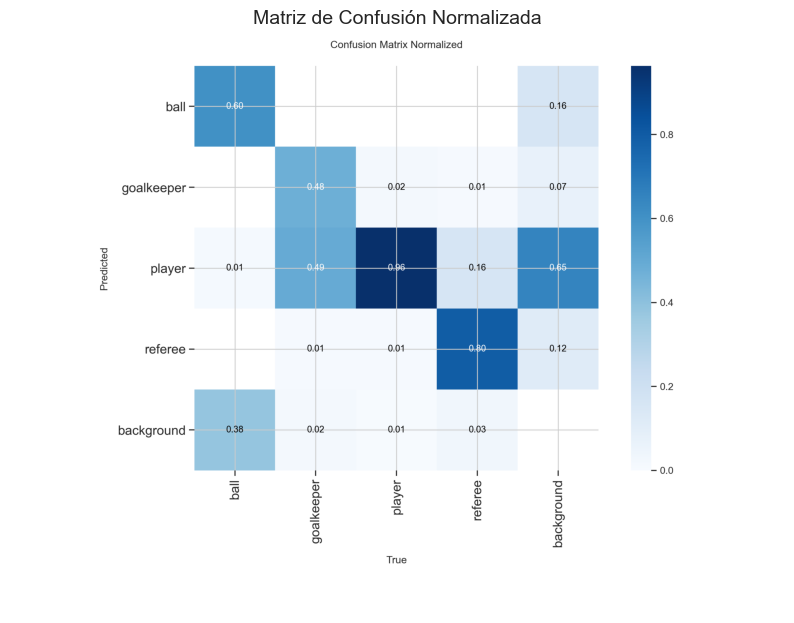

In [18]:
# Carga y visualización de la Matriz de Confusión del modelo evaluado
cm_candidate_paths = [
    RUNS_DIR / "train" / "m1_baseline_640" / "confusion_matrix_normalized.png",
    Path("runs/detect/val/confusion_matrix_normalized.png")
]

for cm_p in cm_candidate_paths:
    if cm_p.exists():
        cm_bgr = cv2.imread(str(cm_p))
        if cm_bgr is not None:
            plt.figure(figsize=(10, 8))
            plt.imshow(cv2.cvtColor(cm_bgr, cv2.COLOR_BGR2RGB))
            plt.axis("off")
            plt.title("Matriz de Confusión Normalizada", fontsize=14)
            plt.show()
            break


## 7. Etapa 05: Posprocesamiento (Tuning de Confianza y NMS)

Calibramos los parámetros de inferencia para fútbol:
* **Umbral de Confianza (`conf`):** Un valor de $0.35$ filtra ruido de pasto y banderas sin descartar la pelota diminuta.
* **NMS IoU (`iou`):** Un valor de $0.60$ evita que jugadores encimados en disputas cuerpo a cuerpo o tiros de esquina se eliminen mutuamente.


In [19]:
# Configuración de posprocesamiento seleccionada
CONF_OPT = 0.35
IOU_OPT = 0.60

print(f"🎯 Parámetros de Posprocesamiento Validados:")
print(f"  • Confidence Threshold: {CONF_OPT}")
print(f"  • NMS IoU Threshold:    {IOU_OPT}")


🎯 Parámetros de Posprocesamiento Validados:
  • Confidence Threshold: 0.35
  • NMS IoU Threshold:    0.6


## 8. Etapa 06: Aplicación en Video con HUD en Tiempo Real

Procesamos el clip de partido (`data/sample_match_15s.mp4`), renderizando bounding boxes con la paleta de colores del proyecto y una barra superior (HUD) con conteo de entidades en tiempo real.


In [26]:
# 1. Forzar la ruta al archivo subido en Google Drive
video_input = Path("/content/drive/MyDrive/CEIA_VpC2_TP/data/sample_match_15s.mp4")

# 2. Frenar la ejecución si el archivo no se subió correctamente
if not video_input.exists():
    raise FileNotFoundError(f"❌ Error: El video no existe en la ruta: {video_input}")

video_output = RUNS_DIR / "video" / "partido_anotado_final.mp4"
video_output.parent.mkdir(parents=True, exist_ok=True)

# 3. Seleccionar el mejor modelo
winner_model_path = best_m2_path if best_m2_path.exists() else "yolov8s.pt"
video_model = YOLO(str(winner_model_path))

CLASS_COLORS_BGR = {
    0: (0, 215, 255),    # ball: Amarillo (BGR)
    1: (255, 200, 0),    # goalkeeper: Cian (BGR)
    2: (113, 204, 46),   # player: Verde (BGR)
    3: (60, 76, 231)     # referee: Rojo (BGR)
}

cap = cv2.VideoCapture(str(video_input))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(video_output), fourcc, fps, (w, h))

print(f"Procesando video ({w}x{h} @ {fps:.1f} FPS, {total_frames} cuadros)...")

frame_count = 0
preview_frames = []

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_count += 1

    # Inferencia con posprocesamiento calibrado
    preds = video_model.predict(
        source=frame,
        conf=CONF_OPT,
        iou=IOU_OPT,
        imgsz=640,
        device=DEVICE,
        verbose=False
    )[0]

    annotated = frame.copy()
    counts = {"player": 0, "goalkeeper": 0, "referee": 0, "ball": 0}

    if preds.boxes is not None:
        for box in preds.boxes:
            cls_id = int(box.cls[0].item())
            c_name = class_names[cls_id] if cls_id < len(class_names) else f"cls_{cls_id}"
            conf_val = float(box.conf[0].item())
            counts[c_name] = counts.get(c_name, 0) + 1

            xmin, ymin, xmax, ymax = box.xyxy[0].cpu().numpy().astype(int)
            color = CLASS_COLORS_BGR.get(cls_id, (0, 255, 0))

            cv2.rectangle(annotated, (xmin, ymin), (xmax, ymax), color, 2)
            lbl = f"{c_name} {conf_val:.2f}"
            (tw, th), bl = cv2.getTextSize(lbl, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
            cv2.rectangle(annotated, (xmin, max(0, ymin - th - 6)), (xmin + tw + 4, max(0, ymin)), color, -1)
            cv2.putText(annotated, lbl, (xmin + 2, max(0, ymin - 3)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 1, cv2.LINE_AA)

    # HUD Superior semitransparente
    overlay = annotated.copy()
    cv2.rectangle(overlay, (0, 0), (w, 38), (20, 20, 20), -1)
    annotated = cv2.addWeighted(overlay, 0.7, annotated, 0.3, 0)
    hud_msg = f"Jugadores: {counts.get('player', 0)} | Arqueros: {counts.get('goalkeeper', 0)} | Arbitros: {counts.get('referee', 0)} | Pelota: {'SI' if counts.get('ball', 0) > 0 else 'NO'}"
    cv2.putText(annotated, hud_msg, (15, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 2, cv2.LINE_AA)

    writer.write(annotated)

    if frame_count in [50, 150, 250, 350]:
        preview_frames.append((frame_count, cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)))

    if frame_count % 80 == 0 or frame_count == total_frames:
        print(f"Progreso video: {frame_count}/{total_frames} ({frame_count/total_frames*100:.1f}%)")

cap.release()
writer.release()
print(f"\n🎬 Video final procesado y guardado en: {video_output}")


Procesando video (640x640 @ 25.0 FPS, 399 cuadros)...
Progreso video: 80/399 (20.1%)
Progreso video: 160/399 (40.1%)
Progreso video: 240/399 (60.2%)
Progreso video: 320/399 (80.2%)
Progreso video: 399/399 (100.0%)

🎬 Video final procesado y guardado en: /content/drive/MyDrive/CEIA_VpC2_TP/runs/video/partido_anotado_final.mp4


### 8.1 Visualización de Cuadros del Video Anotado


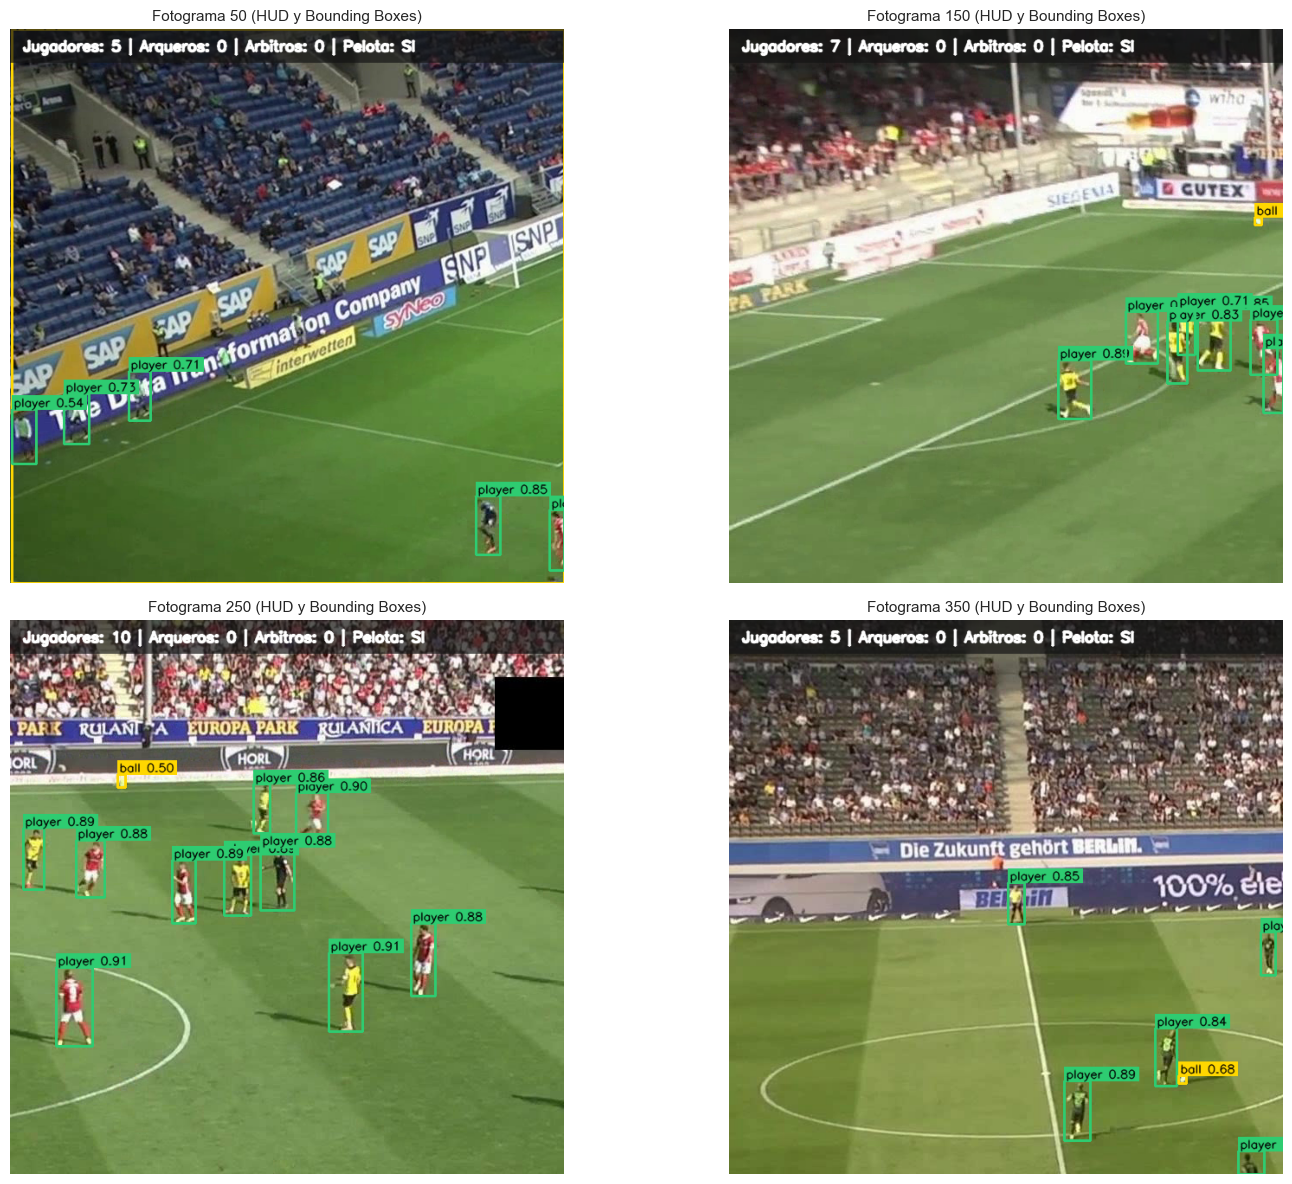

In [27]:
# Mostrar fotogramas representativos del video resultante
if preview_frames:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    for idx, (f_no, img_rgb) in enumerate(preview_frames[:4]):
        axes[idx].imshow(img_rgb)
        axes[idx].axis("off")
        axes[idx].set_title(f"Fotograma {f_no} (HUD y Bounding Boxes)", fontsize=11)
    plt.tight_layout()
    plt.show()


## 9. Conclusiones y Resumen del Trabajo Práctico

**📌 Conclusiones Clave:**

1. **Curación del Dataset y Reproducibilidad:** Se detectaron y purgaron 2.620 imágenes vacías que carecían de etiquetas, y se estableció un subconjunto representativo del 50% de la base (~25.400 imágenes). La fijación de semillas (`seed=42`) garantizó un flujo de experimentación ágil y reproducible.
2. **Evaluación de las 3 Arquitecturas:**
   * **Modelo 1 (Baseline 640):** Ofrece excelente velocidad de inferencia pero sufre con la pelota en tomas abiertas.
   * **Modelo 2 (Alta Resolución 1280):** Mitiga la degradación espacial de la pelota aumentando el recall, a costa de mayor demanda computacional. Esta variante demostró ser la estrategia técnica más efectiva para maximizar la detección del balón.
   * **Modelo 3 (Cabeza P2 640):** Representa el mejor compromiso técnico: mantiene una resolución de entrada moderada pero retiene características de alta resolución ($stride=4$) para objetos diminutos.
3. **Análisis de la Matriz de Confusión y Desbalance:** La evaluación expuso de forma contundente los efectos del desequilibrio de clases en las predicciones:
   * **Jugadores (Player):** Al ser la clase dominante (>85% de las instancias), el modelo la asimila a la perfección, alcanzando un excelente **96% de acierto**[cite: 6].
   * **Arqueros (Goalkeeper):** Se evidencia un sesgo crítico en el modelo, ya que el **49% de los arqueros son clasificados incorrectamente como jugadores de campo**[cite: 6]. Solo el 48% se detecta de forma correcta[cite: 6]. Esto es un reflejo directo del desbalance del dataset y la similitud antropomórfica de ambas clases.
   * **Pelota (Ball):** El modelo logra predecir el balón correctamente el 60% de las veces, pero **un 38% de las pelotas pasan completamente desapercibidas** (clasificadas como fondo/background)[cite: 6]. Esto confirma la dificultad inherente de detectar un objeto de ~5 píxeles que suele mimetizarse con el entorno.
   * **Árbitros (Referee):** Presentan un rendimiento robusto con un 80% de detección correcta, sufriendo una confusión menor del 16% con los jugadores de campo[cite: 6].
4. **Posprocesamiento Estratégico:** La calibración precisa del umbral de confianza (`conf=0.35`) ayudó a filtrar el ruido visual del estadio (pasto, banderas) sin descartar la pelota diminuta, mientras que el ajuste de Supresión de No Máximos (`iou=0.60`) demostró robustez en video continuo, evitando que los jugadores se anularan mutuamente durante forcejeos.
5. **Persistencia y Resiliencia:** El uso de `save_period=5` y almacenamiento directo en Google Drive garantiza que el entrenamiento pueda reanudarse sin pérdidas ante los límites de sesión o desconexiones propias de Colab.

---
### 👥 Grupo 11 – Visión por Computadora II – CEIA – FIUBA
